<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import skew

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [38]:
# Your code here
college = pd.read_csv("./data/College.csv")
college= college.rename(columns={college.columns[0]: 'School'})
college.head()

,School,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [39]:
# Your code here
print(college.shape)
print(college.isnull().sum())
print(college.dtypes)

(777, 19)
School         0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64
School             str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object


#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [40]:
# Your code here
print(college['PhD'].isna().sum())
print(college['PhD'].dtype)
print(college['PhD'].unique())

college['PhD'] = pd.to_numeric(college['PhD'], errors='coerce')
print(college[college['PhD'].isna()][['School', 'PhD']])

print(college[college['PhD'] > 100][['School', 'PhD']])
college.loc[college['PhD'] > 100, 'PhD'] = 100

college['PhD'] = college['PhD'].fillna(college['PhD'].median())

0
str
<ArrowStringArray>
[ '70',  '29',  '53',  '92',  '76',   '?',  '90',  '89',  '79',  '40',  '82',
  '73',  '60',  '36',  '78',  '48',  '62',  '69',  '83',  '55',  '88',  '57',
  '93',  '85',  '65',  '66',  '81',  '59',  '58',  '68',  '98',  '71',  '74',
  '61',  '35',  '87',  '80',  '63',  '75',  '39',  '99', '100',  '95',  '77',
  '72',  '64',  '10',  '86',  '22',  '50',  '41',   '8',  '67',  '94',  '56',
  '46',  '54',  '84',  '97',  '51',  '42',  '49',  '52',  '43',  '37',  '45',
  '47',  '91',  '31',  '96',  '34',  '33',  '44',  '32',  '14', '103',  '26',
  '16']
Length: 78, dtype: str
                                  School  PhD
5                      Albertson College  NaN
16                       Amherst College  NaN
44                        Beloit College  NaN
46                   Benedictine College  NaN
56      Bloomsburg Univ. of Pennsylvania  NaN
68                   Bridgewater College  NaN
92               Castleton State College  NaN
112       Christopher Newport 

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [41]:
# Your code here
print(college['Grad.Rate'].isna().sum())
print(college['Grad.Rate'].dtype)
print(college['Grad.Rate'].unique())

print(college[college['Grad.Rate'] > 100][['School', 'Grad.Rate']])
college.loc[college['Grad.Rate'] > 100, 'Grad.Rate'] = 100


0
int64
[ 60  56  54  59  15  55  63  73  80  52  76  74  68  69 100  46  34  48
  70  65  88  58  71  85  79  91  72  84  49  82  35  51  75  53  96  67
  18  33  97  89  93  78  83  61  81  64  62 118  24  66  47  50  21  87
  77  43  95  37  99  45  42  98  94  38  86  44  22  57  29  36  39  40
  26  90  92  32  27  41  31  10  30]
               School  Grad.Rate
95  Cazenovia College        118


## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [42]:
%%writefile myutils.py
import pandas as pd
from scipy.stats import skew as skew_func

def skew_calc(college):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    rows = []

    for col in college.select_dtypes(include='number').columns:
        if college[col].nunique() <= 2:
            continue

        col_skew = skew_func(college[col], bias=False)

        if col_skew < -1:
            degree, direction = 'High', 'Left'
        elif col_skew < -0.5:
            degree, direction = 'Moderate', 'Left'
        elif col_skew <= 0.5:
            degree, direction = 'Normal', 'Symmetrical'
        elif col_skew <= 1:
            degree, direction = 'Moderate', 'Right'
        else:
            degree, direction = 'High', 'Right'

        if degree == 'Normal':
            recommendation = 'No Transformation Needed'
        elif college[col].min() < 0:
            recommendation = 'Yeo-Johnson'
        elif college[col].min() == 0:
            recommendation = 'Log Plus One'
        else:
            recommendation = 'Box-Cox'

        rows.append({
            'Feature': col,
            'Skewness': round(col_skew, 4),
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommendation
        })

    return pd.DataFrame(rows)

Overwriting myutils.py


In [43]:
# Now import the function from myutils
from myutils import skew_calc

In [48]:
def plot_transformations(college, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after
    distributions side by side with the skewness degree on each subplot.
    """
    for _, row in skew_table.iterrows():
        col = row['Feature']
        method = row['Recommended Transformation']

        if method == 'No Transformation Needed':
            continue

        before = college[col]

        if method == 'Log Plus One':
            after = np.log1p(before)
        elif method == 'Box-Cox':
            pt = PowerTransformer(method='box-cox')
            after = pt.fit_transform(before.values.reshape(-1, 1)).flatten()
        else:
            pt = PowerTransformer(method='yeo-johnson')
            after = pt.fit_transform(before.values.reshape(-1, 1)).flatten()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

        ax1.hist(before, bins=30)
        ax1.set_title(f'{col} - Before (skew={skew(before, bias=False):.2f})')

        ax2.hist(after, bins=30)
        ax2.set_title(f'{col} - After (skew={skew(after, bias=False):.2f})')

        plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [49]:
# Your code here
skew_table = skew_calc(college)
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.7237,High,Right,Box-Cox
1,Accept,3.4177,High,Right,Box-Cox
2,Enroll,2.6905,High,Right,Box-Cox
3,Top10perc,1.4132,High,Right,Box-Cox
4,Top25perc,0.2593,Normal,Symmetrical,No Transformation Needed
5,F.Undergrad,2.6105,High,Right,Box-Cox
6,P.Undergrad,5.6924,High,Right,Box-Cox
7,Outstate,0.5093,Moderate,Right,Box-Cox
8,Room.Board,0.4774,Normal,Symmetrical,No Transformation Needed
9,Books,3.4850,High,Right,Box-Cox


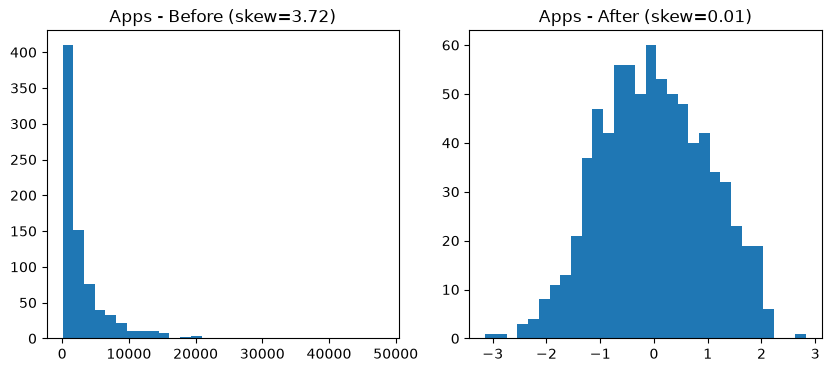

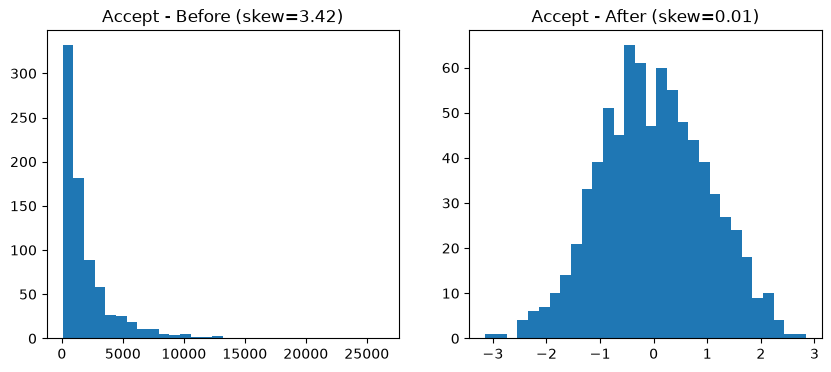

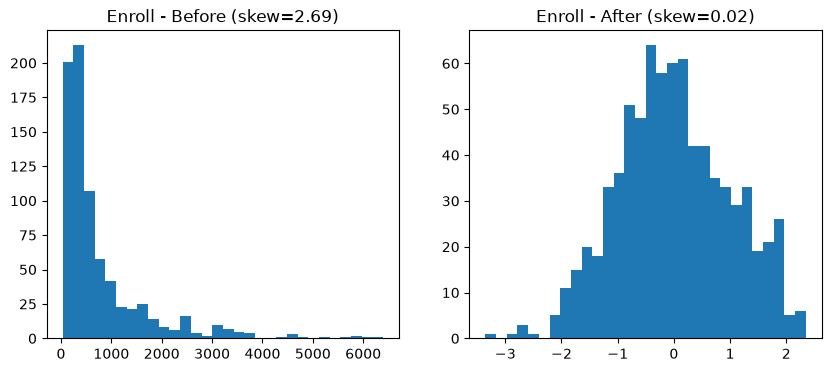

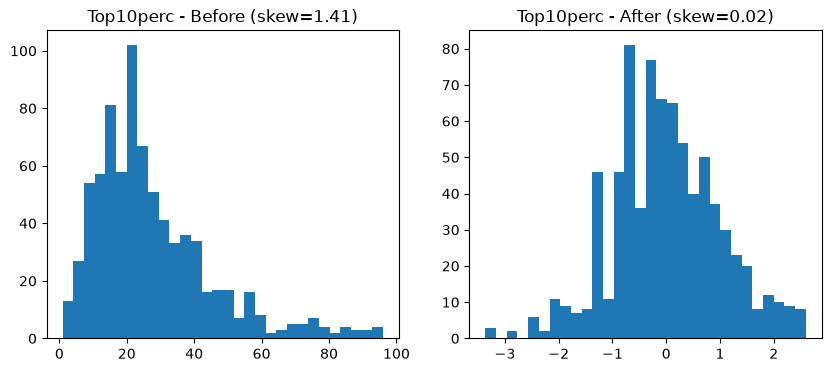

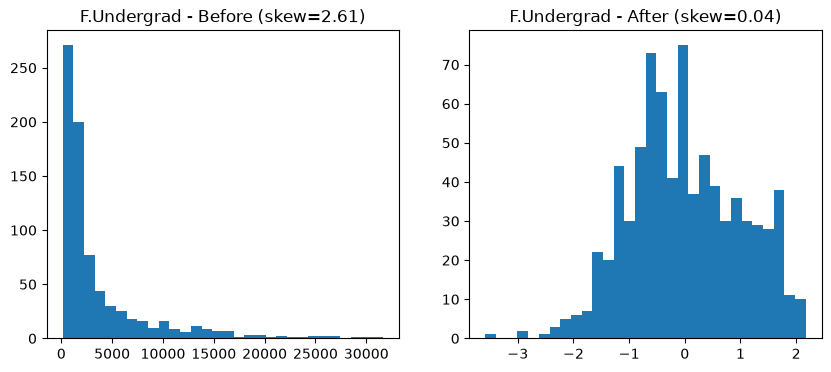

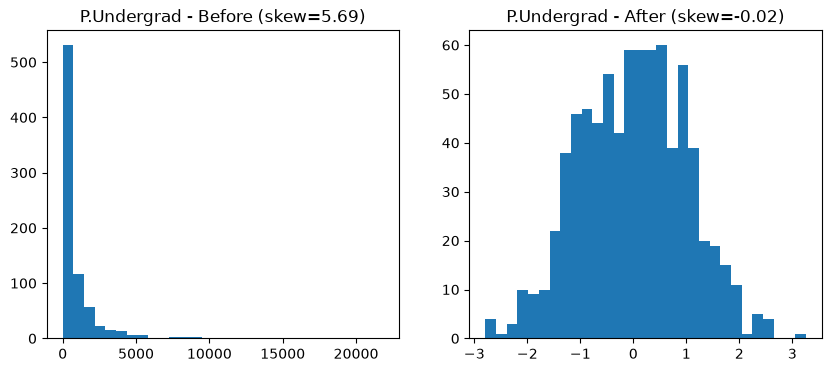

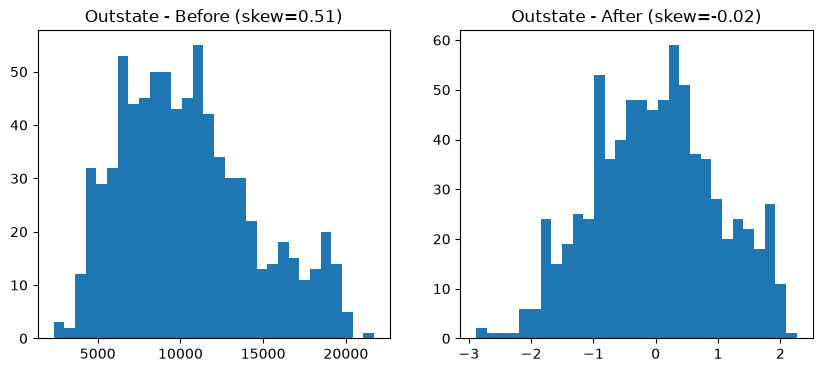

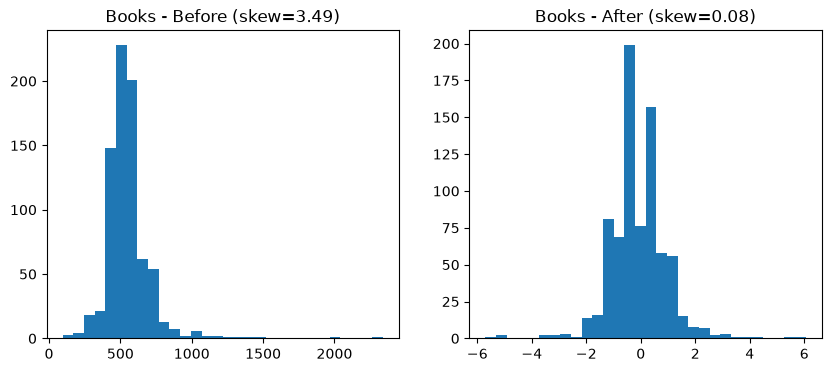

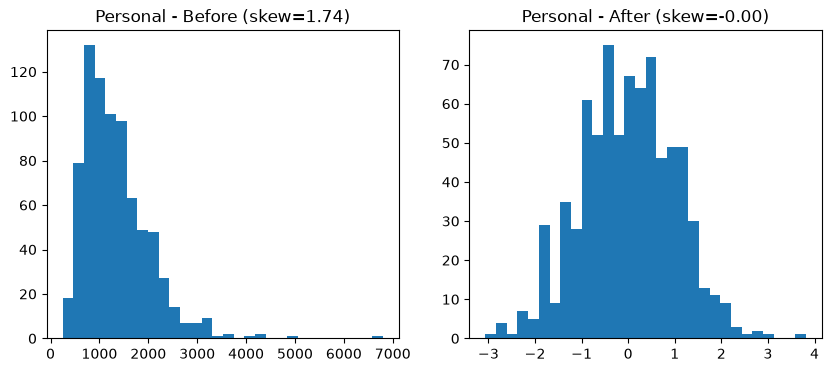

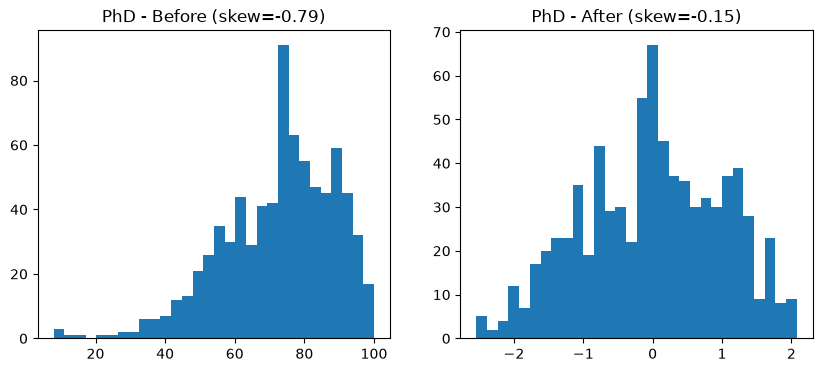

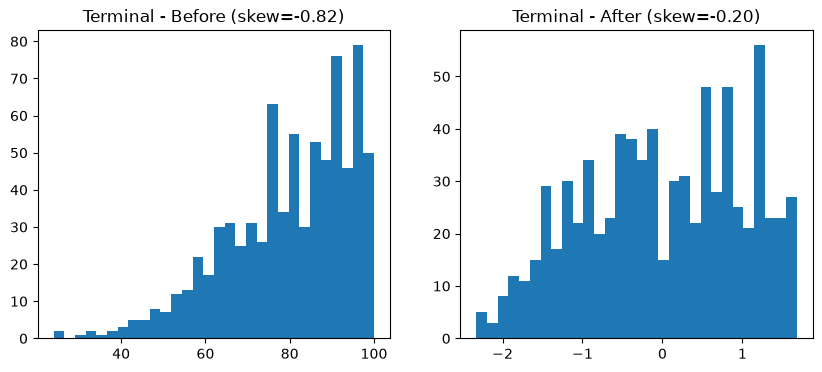

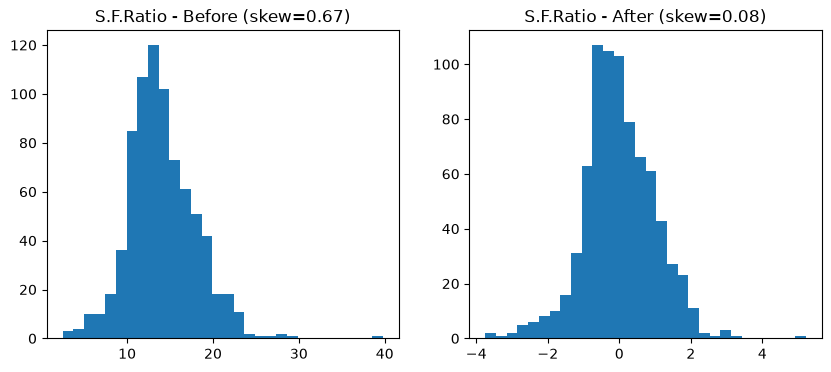

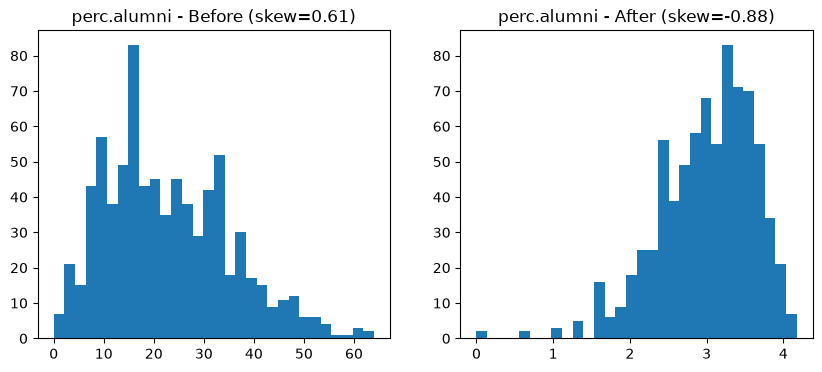

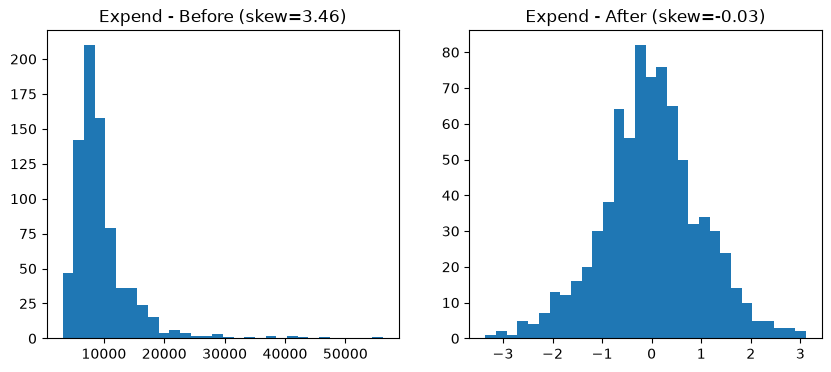

In [50]:
# Your code here
plot_transformations(college, skew_table)

In [47]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [51]:
trans_cols = []

for i in range(len(skew_table)):
    col = skew_table['Feature'].iloc[i]
    method = skew_table['Recommended Transformation'].iloc[i]

    if method == 'No Transformation Needed':
        continue

    new_col = col + '_trans'

    if method == 'Log Plus One':
        college[new_col] = np.log1p(college[col])

    if method == 'Box-Cox':
        pt = PowerTransformer(method='box-cox')
        college[new_col] = pt.fit_transform(college[[col]])

    if method == 'Yeo-Johnson':
        pt = PowerTransformer(method='yeo-johnson')
        college[new_col] = pt.fit_transform(college[[col]])

    trans_cols.append(new_col)

trans_cols

['Apps_trans',
 'Accept_trans',
 'Enroll_trans',
 'Top10perc_trans',
 'F.Undergrad_trans',
 'P.Undergrad_trans',
 'Outstate_trans',
 'Books_trans',
 'Personal_trans',
 'PhD_trans',
 'Terminal_trans',
 'S.F.Ratio_trans',
 'perc.alumni_trans',
 'Expend_trans']

## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [52]:
# Your code here 
college['Accept_Rate'] = college['Accept'] / college['Apps']
college[['Apps', 'Accept', 'Accept_Rate']].head()

,Apps,Accept,Accept_Rate
0,1660,1232,0.742169
1,2186,1924,0.880146
2,1428,1097,0.768207
3,417,349,0.836930
4,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [53]:
# Your code here 
college['Outstate_Tier'] = pd.cut(
    college['Outstate'],
    bins=[0, 7500, 12500, 17500, 25000],
    labels=['Low', 'Medium', 'High', 'Very High']
)
college['Outstate_Tier'].value_counts()


Outstate_Tier
Medium       357
Low          207
High         157
Very High     56
Name: count, dtype: int64

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [54]:
# Your code here 
tier_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
college['Outstate_Tier_Encoded'] = college['Outstate_Tier'].map(tier_order)
college[['Outstate', 'Outstate_Tier', 'Outstate_Tier_Encoded']].head()


,Outstate,Outstate_Tier,Outstate_Tier_Encoded
0,7440,Low,0
1,12280,Medium,1
2,11250,Medium,1
3,12960,High,2
4,7560,Medium,1


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [55]:
# Your code here 
college['Private_Encoded'] = college['Private'].map({'Yes': 1, 'No': 0})
college[['Private', 'Private_Encoded']].head()


,Private,Private_Encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [61]:
cols_to_scale = []
cols_to_scale = trans_cols + ['Outstate_Tier_Encoded', 'Private_Encoded']

scaler = StandardScaler()
scaled_cols = [c + '_scaled' for c in cols_to_scale]
college[scaled_cols] = scaler.fit_transform(college[cols_to_scale])

college[scaled_cols].head()

# Your code here 

,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Outstate_Tier_Encoded_scaled,Private_Encoded_scaled
0,0.027794,0.041028,0.493375,-0.053119,0.433599,0.300156,-0.693449,-0.614254,1.271398,-0.291316,-0.282374,1.017946,-0.722701,-0.491183,-1.246515,0.612553
1,0.282920,0.485821,0.142214,-0.584905,0.365382,0.868239,0.556268,1.302365,0.456551,-2.177859,-2.248129,-0.435083,-0.284489,0.552362,-0.092114,0.612553
2,-0.113916,-0.077046,-0.315977,-0.120942,-0.636774,-0.727254,0.322011,-1.038575,-0.068655,-1.262773,-1.040711,-0.250216,0.696881,0.096393,-0.092114,0.612553
3,-1.332769,-1.294446,-1.396388,1.614476,-1.531207,-0.974032,0.703926,-0.614254,-0.651734,1.363504,1.364588,-1.741872,1.029462,1.726997,1.062286,0.612553
4,-2.153050,-2.287608,-2.659212,-0.584905,-2.588901,0.625418,-0.656776,1.553608,0.456551,0.115517,-0.687052,-0.515571,-3.117978,0.637044,-0.092114,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

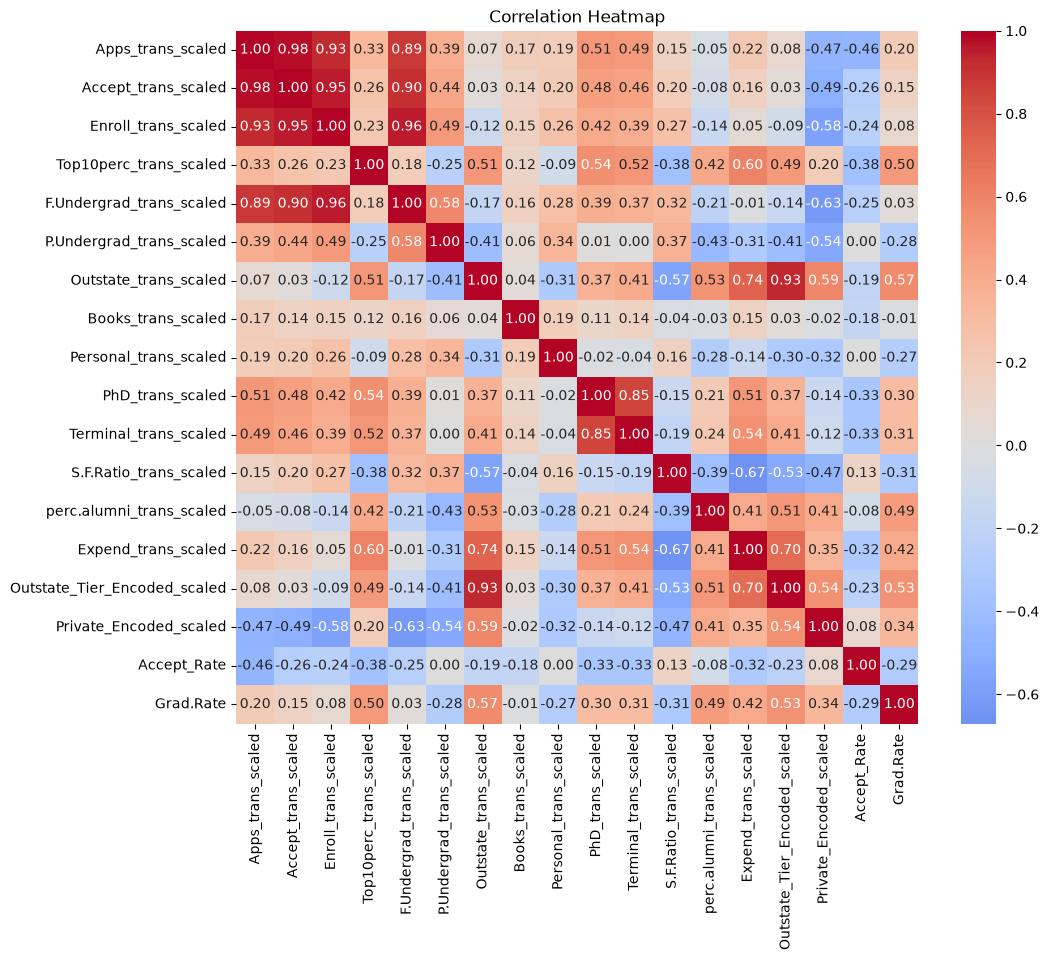

Grad.Rate                       1.000000
Outstate_trans_scaled           0.569032
Outstate_Tier_Encoded_scaled    0.533373
Top10perc_trans_scaled          0.495577
perc.alumni_trans_scaled        0.490135
Expend_trans_scaled             0.417198
Private_Encoded_scaled          0.336490
Terminal_trans_scaled           0.310527
PhD_trans_scaled                0.304436
Apps_trans_scaled               0.202301
Accept_trans_scaled             0.147975
Enroll_trans_scaled             0.078194
F.Undergrad_trans_scaled        0.033344
Books_trans_scaled             -0.005470
Personal_trans_scaled          -0.269853
P.Undergrad_trans_scaled       -0.278290
Accept_Rate                    -0.289299
S.F.Ratio_trans_scaled         -0.310808
Name: Grad.Rate, dtype: float64


In [62]:
corr_features = scaled_cols + ['Accept_Rate', 'Grad.Rate']
corr_matrix = college[corr_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print(corr_matrix['Grad.Rate'].sort_values(ascending=False))

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [63]:
# Your code here 
target = 'Grad.Rate'

X = college.drop(columns=[target])
y = college[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 15. Fit a linear regression using the raw predictors


In [64]:
untrans_predictors = [
    'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad',
    'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD',
    'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend'
]

lr_raw = LinearRegression()
lr_raw.fit(X_train[untrans_predictors], y_train)

y_pred_raw = lr_raw.predict(X_test[untrans_predictors])
r2_raw = r2_score(y_test, y_pred_raw)
print(f"R2 (raw predictors): {r2_raw:.4f}")

# Your code here 

R2 (raw predictors): 0.5005


#### 16. Fit the same model using the log-transformed predictors

In [65]:
trans_predictors = [col + '_trans' if col + '_trans' in college.columns else col for col in untrans_predictors]

lr_trans = LinearRegression()
lr_trans.fit(X_train[trans_predictors], y_train)

y_pred_trans = lr_trans.predict(X_test[trans_predictors])
r2_trans = r2_score(y_test, y_pred_trans)
print(f"R2 (transformed predictors): {r2_trans:.4f}")

# Your code here 

R2 (transformed predictors): 0.5021


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [66]:
# Your code here 
print(f"R2 raw:         {r2_raw:.4f}")
print(f"R2 transformed: {r2_trans:.4f}")
print(f"Improvement:    {r2_trans - r2_raw:+.4f}")

R2 raw:         0.5005
R2 transformed: 0.5021
Improvement:    +0.0016


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [67]:
# Your code here 
college.to_csv('college_transformed.csv', index=False)